# Tiny Dreamer Highway — Iter 20: Lower Entropy Weight

**Name:** Esteban  
**Course:** CSC 580 AI 2  
**Assignment:** Final Project — Dream the Road  
**AI tools consulted:** GitHub Copilot

**Base:** iter5 + iter10 + iter17 (steering_penalty=0.025, max_episode_steps=120, batch_size=384)  
**New change:** `actor_entropy_weight: 0.003 → 0.001`  
**Hypothesis:** Iter 19's 0.003 entropy weight made the policy too exploratory, causing full-throttle aggressive behavior. A gentler 0.001 should preserve traffic awareness while letting the policy converge on smoother control.

## Iteration 20 — Gentler entropy (Phase 4, iter 19 base)

Iter 19 (entropy=0.003) produced the best traffic awareness but was too aggressive/sporadic. Reducing entropy weight to 0.001 — still enough to prevent std collapse, but less pressure to explore randomly.

In [1]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')
REPO_URL = 'https://github.com/estmon8u/CSC_580_Final_Project.git'
DRIVE_ROOT = Path('/content/drive/MyDrive/CSC_580_Final_Project')
ARTIFACT_ROOT = DRIVE_ROOT / 'artifacts'

for path in [DRIVE_ROOT, ARTIFACT_ROOT, ARTIFACT_ROOT / 'training_runs']:
    path.mkdir(parents=True, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%%bash
set -e
REPO_URL='https://github.com/estmon8u/CSC_580_Final_Project.git'
BRANCH='main'
if [ ! -d /content/CSC_580_Final_Project/.git ]; then
  git clone -b "${BRANCH}" "${REPO_URL}" /content/CSC_580_Final_Project
else
  cd /content/CSC_580_Final_Project
  git fetch origin "${BRANCH}"
  git checkout "${BRANCH}"
  git pull --ff-only origin "${BRANCH}"
fi
cd /content/CSC_580_Final_Project
python -m pip install --upgrade pip --quiet
python -m pip install -e . --quiet

Your branch is up to date with 'origin/main'.
Already up to date.


From https://github.com/estmon8u/CSC_580_Final_Project
 * branch            main       -> FETCH_HEAD
Already on 'main'
From https://github.com/estmon8u/CSC_580_Final_Project
 * branch            main       -> FETCH_HEAD


In [3]:
import json
import sys
import torch
from pathlib import Path

PROJECT_ROOT = Path('/content/CSC_580_Final_Project')
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from tiny_dreamer_highway.config import load_experiment_config
from tiny_dreamer_highway.training import run_training_experiment

CONFIG_PATH = PROJECT_ROOT / 'notebooks' / 'configs' / 'training_run.yaml'
config = load_experiment_config(CONFIG_PATH)

print(json.dumps(config.model_dump(), indent=2))

gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'none'
print('Loaded config from:', CONFIG_PATH)
print('GPU:', gpu_name)

# --- Iter5 base overrides ---
config.env.action.smoothing_factor = 0.5
config.env.vehicles_count = 12
config.env.npc_speed_scale = 0.65
config.env.reward.normalize_reward = False
config.env.frame_stack = 3

print('\nIter5 base overrides:')
print(f'  smoothing_factor = {config.env.action.smoothing_factor}')
print(f'  vehicles_count = {config.env.vehicles_count}')
print(f'  npc_speed_scale = {config.env.npc_speed_scale}')
print(f'  normalize_reward = {config.env.reward.normalize_reward}')
print(f'  frame_stack = {config.env.frame_stack}')

# --- Iter 10 Override ---
config.env.reward.steering_penalty = 0.025

print('\nIter 10 override:')
print(f'  steering_penalty = {config.env.reward.steering_penalty}')

# --- Iter 17 Overrides ---
config.env.max_episode_steps = 120
config.training.batch_size = 384

print('\nIter 17 overrides:')
print(f'  max_episode_steps = {config.env.max_episode_steps}')
print(f'  batch_size = {config.training.batch_size}')

# --- Iter 20 Override: lower entropy weight ---
config.training.actor_entropy_weight = 0.001

print('\nIter 20 override:')
print(f'  actor_entropy_weight = {config.training.actor_entropy_weight}')

{
  "seed": 7,
  "device": "cuda",
  "env": {
    "env_id": "highway-v0",
    "observation_height": 64,
    "observation_width": 64,
    "frame_stack": 3,
    "max_episode_steps": 120,
    "lanes_count": 4,
    "vehicles_count": 12,
    "npc_speed_scale": 0.65,
    "simulation_frequency": 15,
    "policy_frequency": 5,
    "action": {
      "type": "continuous",
      "longitudinal": true,
      "lateral": true,
      "longitudinal_scale": 0.7,
      "lateral_scale": 0.35,
      "smoothing_factor": 0.5,
      "num_actions": 5
    },
    "reward": {
      "collision_reward": -1.0,
      "right_lane_reward": 0.0,
      "high_speed_reward": 0.8,
      "lane_change_reward": 0.0,
      "overtake_reward": 2.5,
      "normalize_reward": false,
      "reward_speed_range": [
        26.0,
        35.0
      ],
      "offroad_terminal": true,
      "offroad_penalty": 0.5,
      "steering_penalty": 0.025,
      "steering_change_penalty": 0.02
    }
  },
  "replay": {
    "capacity": 500000,
    "

In [4]:
RUN_NAME = 'iter20_low_entropy'
RUN_ARTIFACT_ROOT = ARTIFACT_ROOT / 'training_runs' / RUN_NAME
RUN_ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

CYCLES = 500
WARM_START_STEPS = None
POLICY_STEPS = None
CHECKPOINT_INTERVAL = None
RESUME_FROM = None

print('Run name:', RUN_NAME)
print('Resume from:', RESUME_FROM if RESUME_FROM else '(fresh run — old artifacts will be cleared)')
print('Effective cycles:', config.training.cycles if CYCLES is None else CYCLES)
print('Effective policy steps:', config.training.policy_steps if POLICY_STEPS is None else POLICY_STEPS)

Run name: iter20_low_entropy
Resume from: (fresh run — old artifacts will be cleared)
Effective cycles: 500
Effective policy steps: 32


In [5]:
print('Launching iter20 run. Per-cycle progress lines will appear below.')

training_summary = run_training_experiment(
    config,
    RUN_ARTIFACT_ROOT,
    cycles=CYCLES,
    warm_start_steps=WARM_START_STEPS,
    policy_steps=POLICY_STEPS,
    checkpoint_interval=CHECKPOINT_INTERVAL,
    resume_from=RESUME_FROM,
)

print('Completed cycles:', training_summary.completed_cycles)
print('Latest checkpoint:', training_summary.latest_checkpoint)
print('Latest metrics:', training_summary.latest_record)

Launching iter20 run. Per-cycle progress lines will appear below.
[train] starting run | cycles=500 | start_step=1 | warm_start_steps=10000 | policy_steps=32 | device=cuda
[train] step=1/500 | warm=10000 | policy=32 | replay=10032 | world_total=15149.2401 | actor=-0.4540 | critic=2.6301 | eval_reward=n/a | cycle_s=408.1 | elapsed_s=408.1 | checkpoint=-
[train] step=2/500 | warm=0 | policy=32 | replay=10064 | world_total=13389.3466 | actor=0.9006 | critic=2.1068 | eval_reward=n/a | cycle_s=6.7 | elapsed_s=414.9 | checkpoint=-
[train] step=3/500 | warm=0 | policy=32 | replay=10096 | world_total=12648.4583 | actor=-0.0472 | critic=1.6397 | eval_reward=n/a | cycle_s=6.9 | elapsed_s=421.7 | checkpoint=-
[train] step=4/500 | warm=0 | policy=32 | replay=10128 | world_total=12433.1506 | actor=-0.7225 | critic=1.9515 | eval_reward=n/a | cycle_s=7.2 | elapsed_s=428.9 | checkpoint=-
[train] step=5/500 | warm=0 | policy=32 | replay=10160 | world_total=12147.7325 | actor=-4.1597 | critic=8.6327 | e

In [6]:
summary_path = training_summary.log_dir / 'latest_summary.json'
summary_payload = json.loads(summary_path.read_text(encoding='utf-8'))
summary_payload

{'checkpoint_file': '/content/drive/MyDrive/CSC_580_Final_Project/artifacts/training_runs/iter20_low_entropy/checkpoints/checkpoint_00500.pt',
 'latest_metrics': {'behavior/actor_entropy': -1.4235089272260666,
  'behavior/actor_loss': -8.61575472354889,
  'behavior/critic_loss': 1.837534785270691,
  'behavior/imagined_reward_mean': 1.232421875,
  'behavior/imagined_value_mean': 5.3125,
  'evaluation/crash_rate': 1.0,
  'evaluation/episodes': 10.0,
  'evaluation/mean_reward': 6.592258496184395,
  'evaluation/mean_steps': 14.0,
  'policy_added': 32,
  'replay_size': 26000,
  'step': 500,
  'warm_start_added': 0,
  'world_model/continue_loss': 0.017105502192862332,
  'world_model/kl_loss': 4.469381093978882,
  'world_model/kl_loss_raw': 4.469381093978882,
  'world_model/observation_log_prob': -11312.69873046875,
  'world_model/overshooting_feature_mse': 0.09660517610609531,
  'world_model/overshooting_kl_loss': 4.5121960043907166,
  'world_model/overshooting_pairs': 65.0,
  'world_model/r

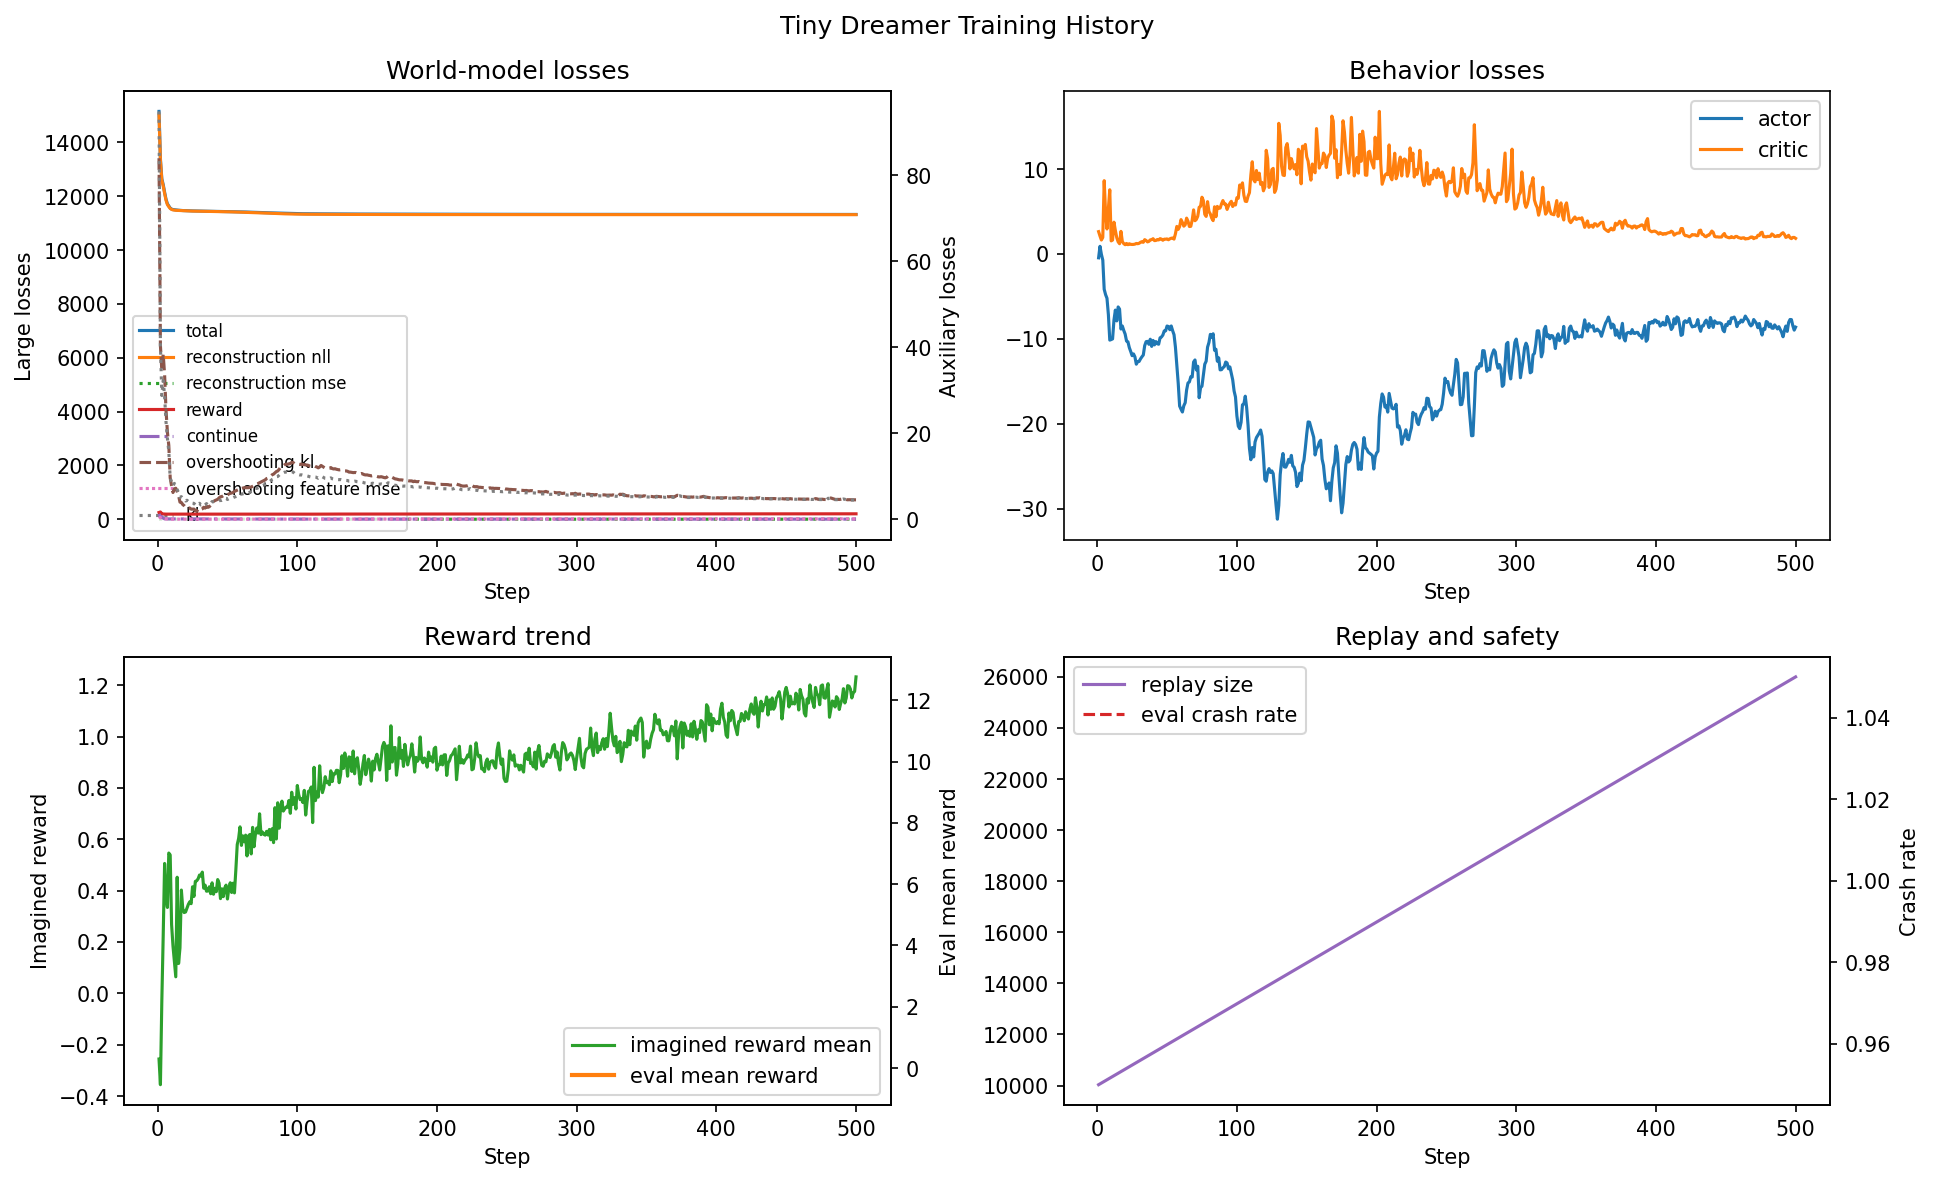

{'analysis_summary': {'best_eval_mean_reward': 12.761022647823328,
  'best_eval_reward_step': 150,
  'best_imagined_reward_mean': 1.232421875,
  'best_imagined_reward_step': 500,
  'best_world_model_step': 499,
  'best_world_model_total_loss': 11320.65966796875,
  'largest_replay_size': 26000,
  'largest_replay_step': 500,
  'last_metrics': {'behavior/actor_entropy': -1.4235089272260666,
   'behavior/actor_loss': -8.61575472354889,
   'behavior/critic_loss': 1.837534785270691,
   'behavior/imagined_reward_mean': 1.232421875,
   'behavior/imagined_value_mean': 5.3125,
   'evaluation/crash_rate': 1.0,
   'evaluation/episodes': 10.0,
   'evaluation/mean_reward': 6.592258496184395,
   'evaluation/mean_steps': 14.0,
   'policy_added': 32,
   'replay_size': 26000,
   'step': 500,
   'warm_start_added': 0,
   'world_model/continue_loss': 0.017105502192862332,
   'world_model/kl_loss': 4.469381093978882,
   'world_model/kl_loss_raw': 4.469381093978882,
   'world_model/observation_log_prob': -1

In [7]:
from IPython.display import Image, display
import csv
import importlib
import json
import tiny_dreamer_highway.evaluation.training_analysis as training_analysis

training_analysis = importlib.reload(training_analysis)
export_training_history_artifacts = training_analysis.export_training_history_artifacts

analysis_outputs = export_training_history_artifacts(
    training_summary.log_dir / 'cycle_metrics.csv',
    RUN_ARTIFACT_ROOT / 'analysis',
    prefix=RUN_NAME,
)

display(Image(filename=str(analysis_outputs['curves'])))
analysis_summary = json.loads(analysis_outputs['summary'].read_text(encoding='utf-8'))
with (training_summary.log_dir / 'cycle_metrics.csv').open('r', encoding='utf-8', newline='') as handle:
    metric_rows = list(csv.DictReader(handle))
latest_metrics_row = metric_rows[-1]
{
    'analysis_summary': analysis_summary,
    'phase4_metrics': {
        'world_model/reconstruction_loss': latest_metrics_row.get('world_model/reconstruction_loss'),
        'world_model/reconstruction_mse': latest_metrics_row.get('world_model/reconstruction_mse'),
        'world_model/observation_log_prob': latest_metrics_row.get('world_model/observation_log_prob'),
        'world_model/overshooting_kl_loss': latest_metrics_row.get('world_model/overshooting_kl_loss'),
        'world_model/overshooting_feature_mse': latest_metrics_row.get('world_model/overshooting_feature_mse'),
        'evaluation/mean_reward': latest_metrics_row.get('evaluation/mean_reward'),
        'evaluation/crash_rate': latest_metrics_row.get('evaluation/crash_rate'),
    },
}

## Agent Driving Demo

Record agent-driving GIFs using the trained policy from this run. These show the actor driving in the real highway-env.

Using demo recorder from: tiny_dreamer_highway.evaluation.policy_rollout
[demo] episode 1/10 | steps=7 | reward=-0.51 | CRASH | saved iter20_low_entropy_ep01.gif
[demo] episode 2/10 | steps=20 | reward=15.34 | CRASH | saved iter20_low_entropy_ep02.gif
[demo] episode 3/10 | steps=8 | reward=2.11 | CRASH | saved iter20_low_entropy_ep03.gif
[demo] episode 4/10 | steps=7 | reward=-0.42 | CRASH | saved iter20_low_entropy_ep04.gif
[demo] episode 5/10 | steps=11 | reward=3.65 | CRASH | saved iter20_low_entropy_ep05.gif
[demo] episode 6/10 | steps=22 | reward=19.54 | CRASH | saved iter20_low_entropy_ep06.gif
[demo] episode 7/10 | steps=6 | reward=-0.73 | CRASH | saved iter20_low_entropy_ep07.gif
[demo] episode 8/10 | steps=14 | reward=5.45 | CRASH | saved iter20_low_entropy_ep08.gif
[demo] episode 9/10 | steps=30 | reward=28.41 | CRASH | saved iter20_low_entropy_ep09.gif
[demo] episode 10/10 | steps=14 | reward=5.31 | CRASH | saved iter20_low_entropy_ep10.gif
[demo] done | avg_reward=7.82 | su

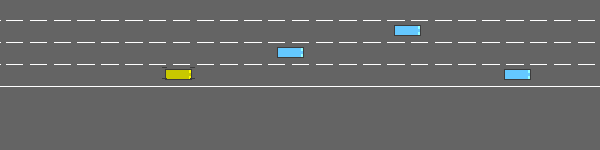


iter20_low_entropy_ep02.gif


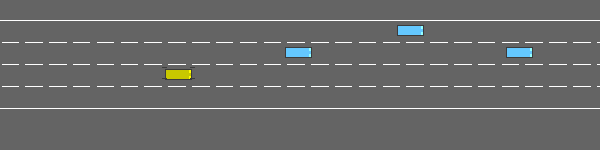


iter20_low_entropy_ep03.gif


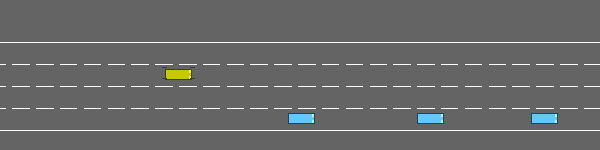


iter20_low_entropy_ep04.gif


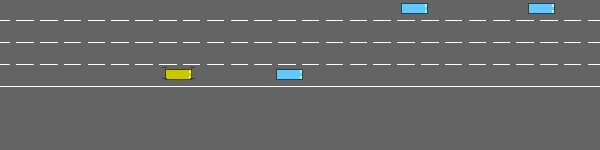


iter20_low_entropy_ep05.gif


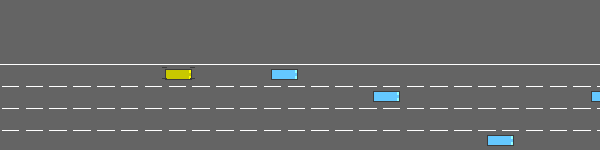


iter20_low_entropy_ep06.gif


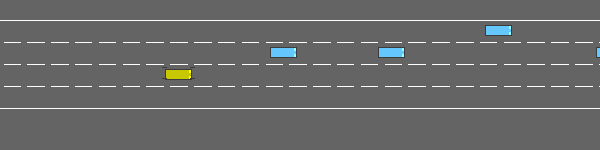


iter20_low_entropy_ep07.gif


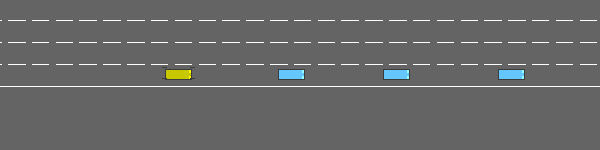


iter20_low_entropy_ep08.gif


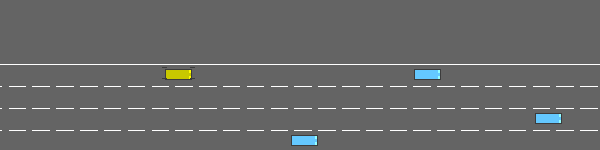


iter20_low_entropy_ep09.gif


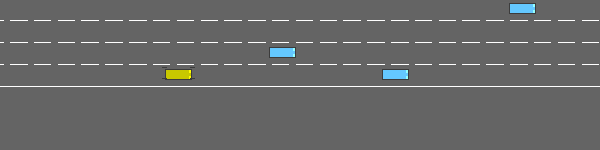


iter20_low_entropy_ep10.gif


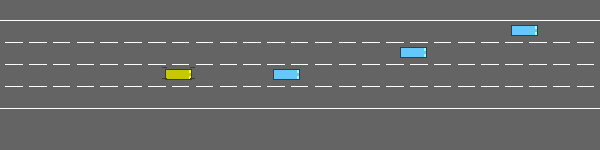

In [8]:
from IPython.display import Image, display
import importlib
import tiny_dreamer_highway.evaluation as evaluation_pkg

try:
    evaluation_pkg = importlib.reload(evaluation_pkg)
    record_demo_videos = evaluation_pkg.record_demo_videos
except (AttributeError, ImportError):
    from tiny_dreamer_highway.evaluation.policy_rollout import record_demo_videos

print('Using demo recorder from:', record_demo_videos.__module__)

demo_outputs = record_demo_videos(
    config,
    checkpoint_path=training_summary.latest_checkpoint,
    output_dir=RUN_ARTIFACT_ROOT / 'demo_videos',
    num_episodes=10,
    max_steps=1000,
    fps=15,
    seed=config.seed,
    prefix=RUN_NAME,
    device=config.device,
)

for gif_path in demo_outputs.video_paths:
    print(f'\n{gif_path.name}')
    display(Image(filename=str(gif_path)))